Beta and sigma convergence are two distinct, complementary concepts in economics analyzing how income levels between economies move over time. Beta convergence occurs when poor economies grow faster than rich ones, narrowing the gap. Sigma convergence measures the reduction in income dispersion (variation) across economies over time

Methods:
1. Beta-convergence (β-convergence): are countries that started with low AI adoption in 2021 growing faster than countries that already had high adoption?
2. Sigma-convergence (σ-convergence): is the spread between countries getting smaller or bigger each year?
3. Country trajectory classification: which countries are leaders, which are stuck, and which managed to catch up?
4. Coefficient of Variation by sector: in which sectors do countries differ the most from each other?
5. Beta-convergence split by firm size: is the divergence problem the same for small and large firms, or is it concentrated in one group?

In [27]:
# Convergence & Growth Analysis - Kamila
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

# same colour palette as the rest of the notebook
BG = "#f8f9fa"
C_NAVY, C_STEEL, C_CORAL, C_GREEN = "#1A3764", "#4682B4", "#E8735A", "#27AE60"
C_RED, C_GOLD, C_GREY = "#E74C3C", "#F1C40F", "#cccccc"
C_BLUE, C_ORANGE = C_STEEL, C_CORAL

EU27 = [
    'Belgium','Bulgaria','Czechia','Denmark','Germany','Estonia',
    'Ireland','Greece','Spain','France','Croatia','Italy','Cyprus',
    'Latvia','Lithuania','Luxembourg','Hungary','Malta','Netherlands',
    'Austria','Poland','Portugal','Romania','Slovenia','Slovakia',
    'Finland','Sweden'
]

# column names from the Eurostat CSV format
SIZE_COL  = "Size classes in number of persons employed"
INDIC_COL = "Information society indicator"
GEO_COL   = "Geopolitical entity (reporting)"
NACE_COL  = "Statistical classification of economic activities in the European Community (NACE Rev. 2)"
UNIT_COL  = "Unit of measure"
YR_COL    = "TIME_PERIOD"
VAL_COL   = "OBS_VALUE"

USE_AI   = ("Enterprises using at least one of the AI technologies: "
            "AI_TTM, AI_TSR, AI_TNLG, AI_TIR, AI_TML, AI_TPA, AI_TAR, E_AI_TPVSG")
ALL_NACE = ("All activities (except agriculture, forestry and fishing, "
            "and mining and quarrying), without financial sector")

SIZE_MAP = {
    "From 10 to 49 persons employed": "Small (10-49)",
    "10 persons employed or more":    "All (10+)",
    "250 persons employed or more":   "Large (250+)",
}

SECTOR_MAP = {
    ALL_NACE:                                                                   "All activities",
    "Manufacturing":                                                            "Manufacturing",
    "Information and communication":                                            "ICT",
    "Construction":                                                             "Construction",
    "Transportation and storage":                                               "Transport & Storage",
    "Professional, scientific and technical activities":                        "Professional & Scientific",
    "Wholesale and retail trade; repair of motor vehicles and motorcycles":     "Wholesale & Retail",
    "Accommodation and food service activities":                                "Accommodation & Food",
}

# same API endpoints as the rest of the notebook
AI_ADOPTION_URL = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
                   "dataflow/ESTAT/isoc_eb_ai/1.0?compress=false&format=csvdata"
                   "&formatVersion=2.0&lang=en&labels=name")
AI_NACE_URL     = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
                   "dataflow/ESTAT/isoc_eb_ain2/1.0?compress=false&format=csvdata"
                   "&formatVersion=2.0&lang=en&labels=name")

print("Setup complete ✓")

Setup complete ✓


In [28]:
# load data from Eurostat API
print("Loading size data from API")
df_ai = pd.read_csv(AI_ADOPTION_URL, low_memory=False)
print(f"size dataset: {df_ai.shape[0]:,} rows")

print("Loading sector data from API")
df_nace = pd.read_csv(AI_NACE_URL, low_memory=False)
print(f"sector dataset: {df_nace.shape[0]:,} rows")

# filter to AI adoption indicator, all NACE sectors, EU27 countries
mask = (
    (df_ai[INDIC_COL] == USE_AI) &
    (df_ai[NACE_COL]  == ALL_NACE) &
    (df_ai[UNIT_COL]  == "Percentage of enterprises") &
    (df_ai[SIZE_COL].isin(SIZE_MAP)) &
    (df_ai[GEO_COL].isin(EU27))
)
df_size = df_ai[mask][[SIZE_COL, GEO_COL, YR_COL, VAL_COL]].copy()
df_size["size"] = df_size[SIZE_COL].map(SIZE_MAP)
df_size = df_size.rename(columns={GEO_COL:"country", YR_COL:"yr", VAL_COL:"value"})
df_size["yr"] = df_size["yr"].astype(int)
df_size["value"] = pd.to_numeric(df_size["value"], errors="coerce")
df_size = df_size[["country","yr","size","value"]].dropna()

# same for sector data
mask_s = (
    (df_nace[INDIC_COL] == USE_AI) &
    (df_nace[UNIT_COL]  == "Percentage of enterprises") &
    (df_nace[SIZE_COL]  == "10 persons employed or more") &
    (df_nace[NACE_COL].isin(SECTOR_MAP)) &
    (df_nace[GEO_COL].isin(EU27))
)
df_sector = df_nace[mask_s][[NACE_COL, GEO_COL, YR_COL, VAL_COL]].copy()
df_sector["sector"] = df_sector[NACE_COL].map(SECTOR_MAP)
df_sector = df_sector.rename(columns={GEO_COL:"country", YR_COL:"yr", VAL_COL:"value"})
df_sector["yr"] = df_sector["yr"].astype(int)
df_sector["value"] = pd.to_numeric(df_sector["value"], errors="coerce")
df_sector = df_sector[["country","yr","sector","value"]].dropna()

YEARS = sorted(df_size["yr"].unique())
print(f"size data: {df_size.shape[0]} rows, years: {YEARS}")
print(f"sector data: {df_sector.shape[0]} rows, sectors: {df_sector['sector'].nunique()}")

Loading size data from API
size dataset: 72,317 rows
Loading sector data from API
sector dataset: 683,476 rows
size data: 324 rows, years: [np.int64(2021), np.int64(2023), np.int64(2024), np.int64(2025)]
sector data: 857 rows, sectors: 8


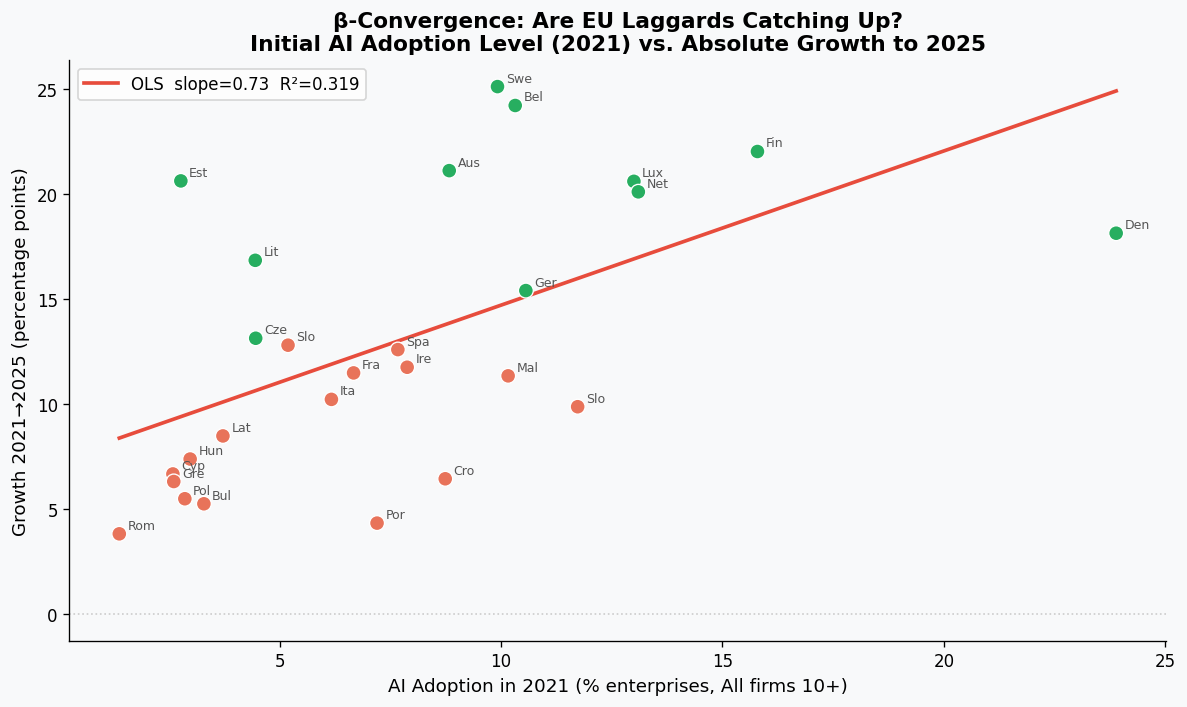

beta-convergence: slope=0.734  R²=0.319  -> DIVERGING

fastest growing (top 5):
  Sweden          +25.1pp  (9.9% -> 35.0%)
  Belgium         +24.2pp  (10.3% -> 34.5%)
  Finland         +22.0pp  (15.8% -> 37.8%)
  Austria         +21.1pp  (8.8% -> 29.9%)
  Estonia         +20.6pp  (2.8% -> 23.4%)

slowest growing (bottom 5):
  Greece          +6.3pp  (2.6% -> 8.9%)
  Poland          +5.5pp  (2.9% -> 8.4%)
  Bulgaria        +5.3pp  (3.3% -> 8.6%)
  Portugal        +4.3pp  (7.2% -> 11.5%)
  Romania         +3.8pp  (1.4% -> 5.2%)


In [29]:
# beta convergence - do laggards grow faster than leaders?
all_firms = df_size[df_size["size"] == "All (10+)"]
base = all_firms[all_firms["yr"] == 2021].set_index("country")["value"]
end  = all_firms[all_firms["yr"] == 2025].set_index("country")["value"]
common = sorted(set(base.index) & set(end.index))

x_base   = np.array([base[c] for c in common])
y_growth = np.array([end[c] - base[c] for c in common])

m, b = np.polyfit(x_base, y_growth, 1)
r2   = np.corrcoef(x_base, y_growth)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

avg_growth = y_growth.mean()
colors = [C_GREEN if g >= avg_growth else C_ORANGE for g in y_growth]
ax.scatter(x_base, y_growth, c=colors, s=80, zorder=3, edgecolors="white", linewidth=0.8)

xfit = np.linspace(x_base.min(), x_base.max(), 200)
ax.plot(xfit, m * xfit + b, color=C_RED, lw=2.2,
        label=f"OLS  slope={m:.2f}  R²={r2:.3f}")
ax.axhline(0, color=C_GREY, lw=1, linestyle=":")

for c, xi, yi in zip(common, x_base, y_growth):
    ax.annotate(c[:3], (xi, yi), textcoords="offset points",
                xytext=(5, 3), fontsize=7.5, color="#555555")

ax.set_xlabel("AI Adoption in 2021 (% enterprises, All firms 10+)", fontsize=11)
ax.set_ylabel("Growth 2021→2025 (percentage points)", fontsize=11)
ax.set_title("β-Convergence: Are EU Laggards Catching Up?\n"
             "Initial AI Adoption Level (2021) vs. Absolute Growth to 2025",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

conv = "CONVERGING" if m < 0 else "DIVERGING"
print(f"beta-convergence: slope={m:.3f}  R²={r2:.3f}  -> {conv}")
print(f"\nfastest growing (top 5):")
growth_s = pd.Series(y_growth, index=common).sort_values(ascending=False)
for c, g in growth_s.head(5).items():
    print(f"  {c:<15} +{g:.1f}pp  ({base[c]:.1f}% -> {end[c]:.1f}%)")
print(f"\nslowest growing (bottom 5):")
for c, g in growth_s.tail(5).items():
    print(f"  {c:<15} {g:+.1f}pp  ({base[c]:.1f}% -> {end[c]:.1f}%)")

The β-convergence test yields a positive slope (β = +0.73, R² = 0.319), indicating divergence rather than catch-up across EU27 enterprises in AI adoption between 2021 and 2025. Countries with higher initial adoption levels tended to grow faster in absolute terms, suggesting that early movers benefit from compounding advantages — access to skilled labour, digital infrastructure, and accumulated organisational know-how. However, the relationship is not deterministic: Estonia and Lithuania, despite low 2021 baselines, achieved growth rates comparable to frontrunners, indicating that targeted policy intervention can override structural disadvantage. At the other extreme, Romania, Bulgaria, and Portugal exhibit persistently low growth, pointing to a risk of a two-speed EU in enterprise AI adoption

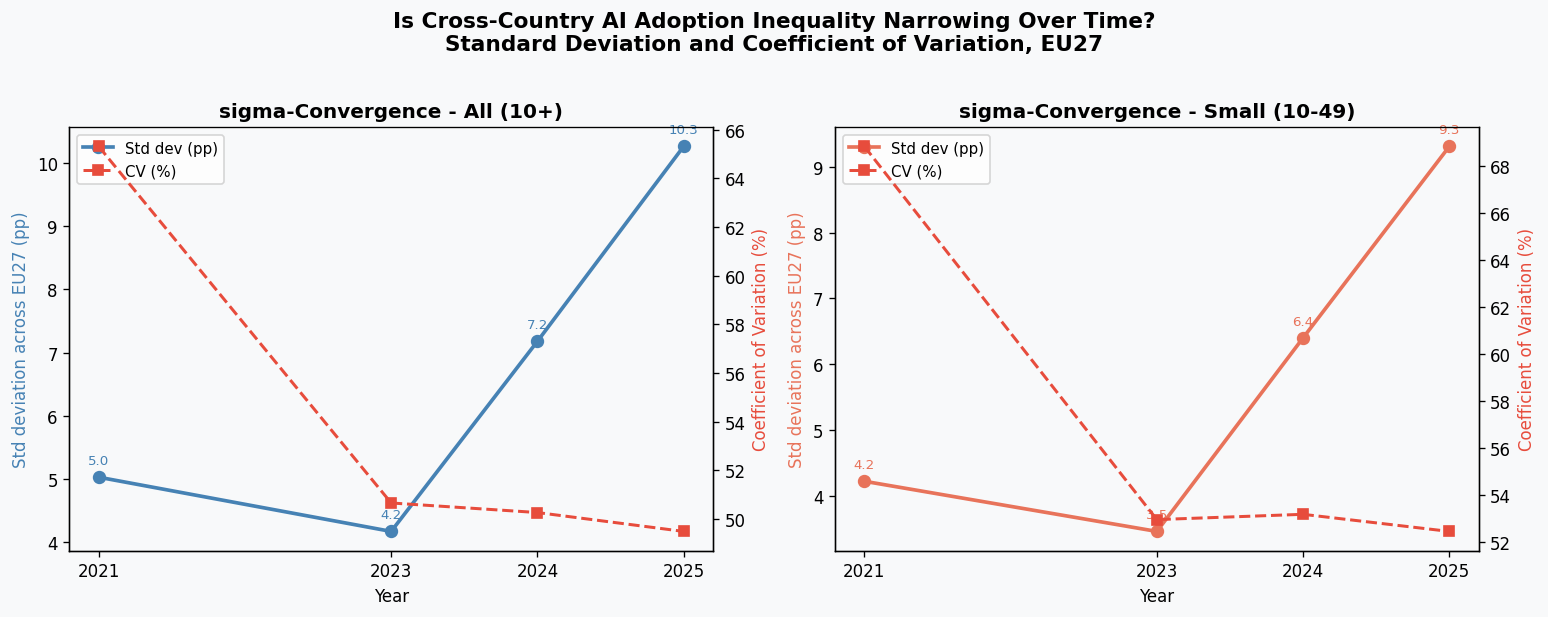

sigma-convergence summary:
  All (10+)           5.0pp -> 10.3pp  (widening)
  Small (10-49)       4.2pp -> 9.3pp  (widening)
  Large (250+)        13.4pp -> 15.0pp  (widening)


In [30]:
# sigma convergence - is the spread between countries narrowing over time?
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

for ax, sz, col in zip(axes, ["All (10+)", "Small (10-49)"], [C_BLUE, C_ORANGE]):
    sub   = df_size[df_size["size"] == sz]
    sigma = sub.groupby("yr")["value"].std()
    mu    = sub.groupby("yr")["value"].mean()
    cv    = sigma / mu * 100

    ax.set_facecolor(BG)
    ax2 = ax.twinx()
    ax.plot(sigma.index, sigma.values, color=col, marker="o", lw=2.2,
            markersize=7, label="Std dev (pp)")
    ax2.plot(cv.index, cv.values, color=C_RED, marker="s", lw=1.8,
             markersize=6, linestyle="--", label="CV (%)")

    for yr, s in sigma.items():
        ax.annotate(f"{s:.1f}", (yr, s), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, color=col)

    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Std deviation across EU27 (pp)", fontsize=10, color=col)
    ax2.set_ylabel("Coefficient of Variation (%)", fontsize=10, color=C_RED)
    ax.set_title(f"sigma-Convergence - {sz}", fontsize=12, fontweight="bold")
    ax.set_xticks(YEARS)
    ax.spines[["top"]].set_visible(False)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

plt.suptitle("Is Cross-Country AI Adoption Inequality Narrowing Over Time?\n"
             "Standard Deviation and Coefficient of Variation, EU27",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("sigma-convergence summary:")
for sz in ["All (10+)", "Small (10-49)", "Large (250+)"]:
    sub   = df_size[df_size["size"] == sz]
    sigma = sub.groupby("yr")["value"].std()
    first, last = sigma.iloc[0], sigma.iloc[-1]
    direction = "narrowing" if last < first else "widening"
    print(f"  {sz:<18}  {first:.1f}pp -> {last:.1f}pp  ({direction})")

The σ-convergence analysis reveals a two-phase dynamic. Between 2021 and 2023, cross-country dispersion narrowed modestly (σ: 5.0pp→4.2pp for all firms), suggesting that early AI adoption was broadly distributed across the EU. However, from 2023 onwards, dispersion accelerated sharply — nearly doubling by 2025 (σ: 4.2pp→10.3pp). This structural break coincides with the mass-market diffusion of generative AI technologies, which disproportionately benefited countries with pre-existing digital infrastructure and human capital. Critically, the divergence is most severe among small firms (σ: 3.5pp→9.3pp, +166%), where the capacity to absorb new AI tools is most sensitive to national-level conditions, while large firms show more muted divergence (σ: 13.4pp→15.0pp), consistent with their ability to adopt across institutional contexts.

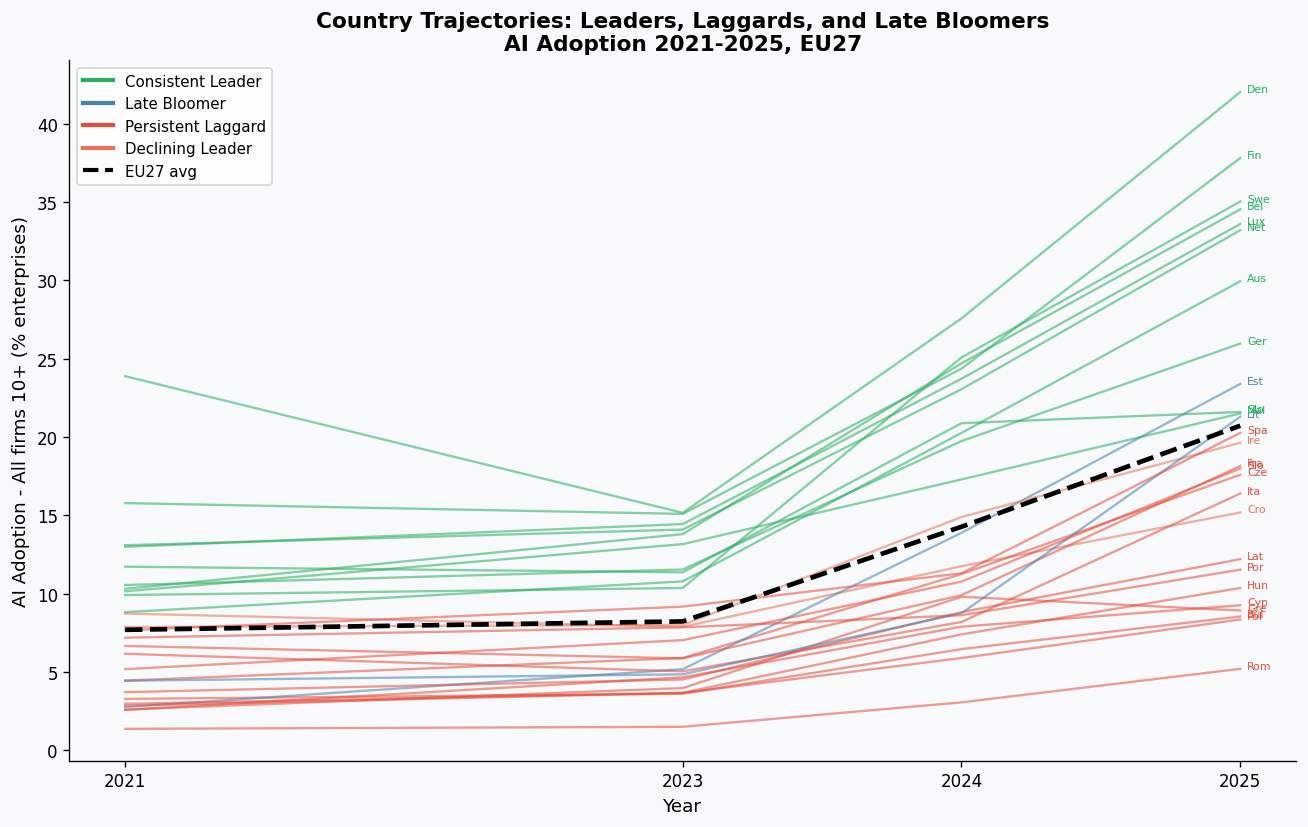

country classification:

  Consistent Leader
    Austria         8.8% -> 29.9%  (+21.1pp)
    Belgium         10.3% -> 34.5%  (+24.2pp)
    Denmark         23.9% -> 42.0%  (+18.1pp)
    Finland         15.8% -> 37.8%  (+22.0pp)
    Germany         10.6% -> 26.0%  (+15.4pp)
    Luxembourg      13.0% -> 33.6%  (+20.6pp)
    Malta           10.2% -> 21.5%  (+11.4pp)
    Netherlands     13.1% -> 33.2%  (+20.1pp)
    Slovenia        11.7% -> 21.6%  (+9.9pp)
    Sweden          9.9% -> 35.0%  (+25.1pp)

  Late Bloomer
    Estonia         2.8% -> 23.4%  (+20.6pp)
    Lithuania       4.5% -> 21.3%  (+16.9pp)

  Persistent Laggard
    Bulgaria        3.3% -> 8.6%  (+5.3pp)
    Cyprus          2.6% -> 9.3%  (+6.7pp)
    Czechia         4.5% -> 17.6%  (+13.1pp)
    France          6.7% -> 18.2%  (+11.5pp)
    Greece          2.6% -> 8.9%  (+6.3pp)
    Hungary         3.0% -> 10.4%  (+7.4pp)
    Italy           6.2% -> 16.4%  (+10.2pp)
    Latvia          3.7% -> 12.2%  (+8.5pp)
    Poland        

In [31]:
# classify each EU27 country by trajectory
all_firms = df_size[df_size["size"] == "All (10+)"]
pivot     = all_firms.pivot(index="country", columns="yr", values="value").dropna()
plot_yrs  = [c for c in pivot.columns if isinstance(c, (int, np.integer))]

eu_avg_21 = pivot[plot_yrs[0]].mean()
eu_avg_25 = pivot[plot_yrs[-1]].mean()

def classify(row):
    l21, l25 = row[plot_yrs[0]], row[plot_yrs[-1]]
    if l21 <  eu_avg_21 and l25 >= eu_avg_25: return "Late Bloomer"
    if l21 >= eu_avg_21 and l25 >= eu_avg_25: return "Consistent Leader"
    if l21 <  eu_avg_21 and l25 <  eu_avg_25: return "Persistent Laggard"
    return "Declining Leader"

pivot["group"] = pivot.apply(classify, axis=1)
group_colors = {
    "Consistent Leader":  C_GREEN,
    "Late Bloomer":       C_BLUE,
    "Persistent Laggard": C_RED,
    "Declining Leader":   C_ORANGE,
}

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_facecolor(BG)

for country, row in pivot.iterrows():
    g = row["group"]
    ax.plot(plot_yrs, row[plot_yrs].values,
            color=group_colors[g], alpha=0.55, lw=1.4)
    ax.annotate(country[:3], (plot_yrs[-1], row[plot_yrs[-1]]),
                textcoords="offset points", xytext=(4, 0),
                fontsize=6.5, color=group_colors[g])

eu_avg = df_size[df_size["size"] == "All (10+)"].groupby("yr")["value"].mean()
ax.plot(eu_avg.index, eu_avg.values, color="black", lw=2.8,
        linestyle="--", zorder=5, label="EU27 average")

handles = [Line2D([0],[0], color=c, lw=2.5, label=g)
           for g, c in group_colors.items()]
handles.append(Line2D([0],[0], color="black", lw=2.5, linestyle="--", label="EU27 avg"))
ax.legend(handles=handles, fontsize=9, loc="upper left")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("AI Adoption - All firms 10+ (% enterprises)", fontsize=11)
ax.set_title("Country Trajectories: Leaders, Laggards, and Late Bloomers\n"
             "AI Adoption 2021-2025, EU27",
             fontsize=13, fontweight="bold")
ax.set_xticks(plot_yrs)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("country classification:")
for g in ["Consistent Leader", "Late Bloomer", "Persistent Laggard", "Declining Leader"]:
    countries = pivot[pivot["group"] == g].index.tolist()
    print(f"\n  {g}")
    for c in countries:
        row = pivot.loc[c, plot_yrs]
        print(f"    {c:<15} {row.iloc[0]:.1f}% -> {row.iloc[-1]:.1f}%  ({row.iloc[-1]-row.iloc[0]:+.1f}pp)")

Country trajectory analysis reveals a highly polarised EU landscape. Ten consistent leaders — concentrated in Northern and Western Europe — maintained above-average adoption throughout and accelerated sharply after 2023, consistent with a 'Matthew effect' where early digital investment compounds over time. Critically, only two countries — Estonia and Lithuania — successfully transitioned from laggard to above-average status, representing the sole cases of genuine catch-up in the sample. Their shared Baltic context and advanced e-government foundations suggest that institutional digitalisation at the national level may be a prerequisite for enterprise-level AI diffusion. The majority of EU27 countries remain persistent laggards, including large economies such as France and Italy, indicating that structural adoption barriers operate independently of country size. The near-absence of late bloomers, combined with the accelerating divergence post-2023, points to a closing window for catch-up as AI adoption increasingly self-reinforces through skill accumulation and organisational learning

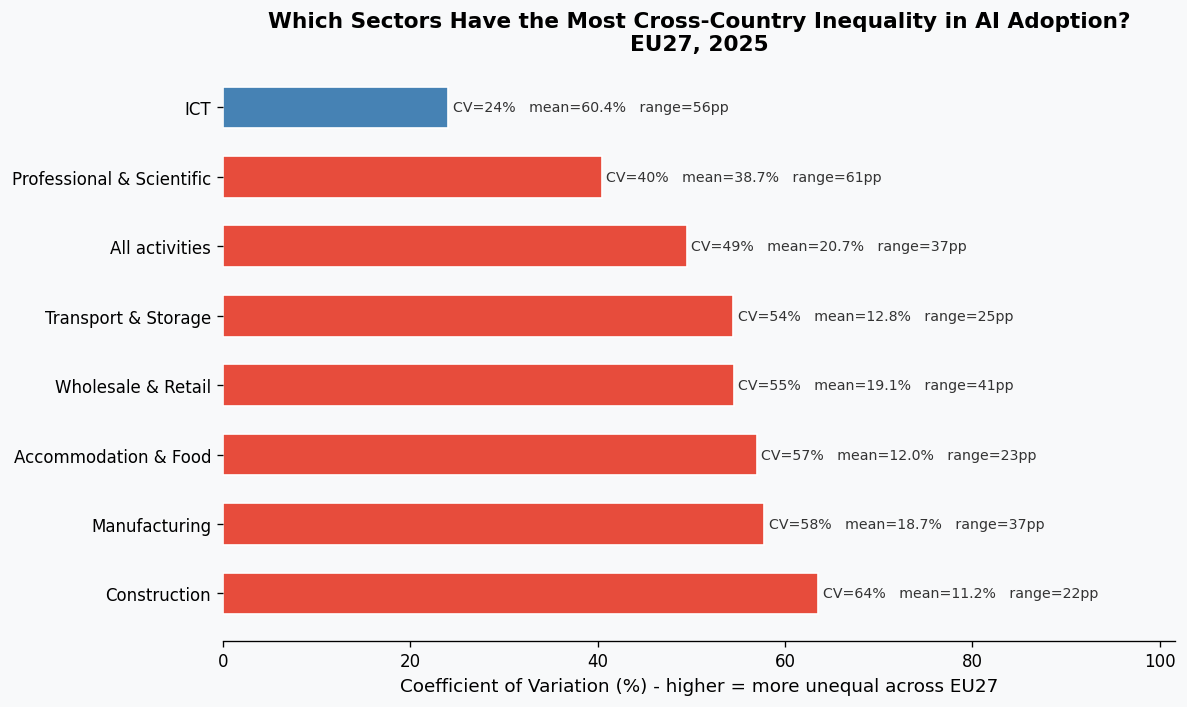

sector inequality table (2025):
                           mean   std    cv   min   max  range
sector                                                        
Construction               11.2   7.1  63.5   2.4  24.0   21.7
Manufacturing              18.7  10.8  57.8   3.2  39.8   36.6
Accommodation & Food       12.0   6.9  57.0   1.7  25.2   23.5
Wholesale & Retail         19.1  10.4  54.5   4.1  44.8   40.7
Transport & Storage        12.8   7.0  54.5   3.0  27.9   24.9
All activities             20.7  10.3  49.5   5.2  42.0   36.8
Professional & Scientific  38.7  15.6  40.4  14.1  74.8   60.6
ICT                        60.4  14.5  24.0  32.1  87.9   55.8


In [32]:
# which sectors are most unequal across EU27 countries in 2025?
sectors_2025 = (df_sector[df_sector["yr"] == 2025]
                .groupby("sector")["value"]
                .agg(["mean","std","min","max"])
                .rename(columns={"mean":"mean","std":"std","min":"min","max":"max"}))
sectors_2025["cv"]    = sectors_2025["std"] / sectors_2025["mean"] * 100
sectors_2025["range"] = sectors_2025["max"] - sectors_2025["min"]
sectors_2025 = sectors_2025.sort_values("cv", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

ax.barh(sectors_2025.index, sectors_2025["cv"],
        color=[C_RED if v > 40 else C_BLUE for v in sectors_2025["cv"]],
        edgecolor="white", height=0.6)

for i, (idx, row) in enumerate(sectors_2025.iterrows()):
    ax.text(row["cv"] + 0.5, i,
            f"CV={row['cv']:.0f}%   mean={row['mean']:.1f}%   range={row['range']:.0f}pp",
            va="center", fontsize=8.5, color="#333333")

ax.set_xlabel("Coefficient of Variation (%) - higher = more unequal across EU27", fontsize=11)
ax.set_title("Which Sectors Have the Most Cross-Country Inequality in AI Adoption?\n"
             "EU27, 2025", fontsize=13, fontweight="bold")
ax.spines[["top","right","left"]].set_visible(False)
ax.set_xlim(0, sectors_2025["cv"].max() * 1.6)
plt.tight_layout()
plt.show()

print("sector inequality table (2025):")
print(sectors_2025[["mean","std","cv","min","max","range"]].round(1).to_string())

Sector-level analysis reveals a striking inverse relationship between average AI adoption and cross-country inequality. The ICT sector, with the highest mean adoption (60.4%), exhibits the lowest coefficient of variation (CV=24%), indicating that competitive pressure in a globally integrated sector drives convergence regardless of national context. By contrast, Construction (mean=11.2%, CV=64%) and Manufacturing (mean=18.7%, CV=58%) show extreme cross-country dispersion, with ranges of 22pp and 37pp respectively, reflecting their dependence on local regulation, firm size structure, and national digital policy. This pattern suggests a dual-speed sectoral dynamic: globally exposed sectors self-converge while domestically embedded sectors amplify national institutional differences. Crucially, countries whose economic structure is weighted toward high-CV sectors face a compounding disadvantage — not only do these sectors adopt AI more slowly on average, but the gap between their best and worst performers is largest, making EU-wide catch-up structurally more difficult

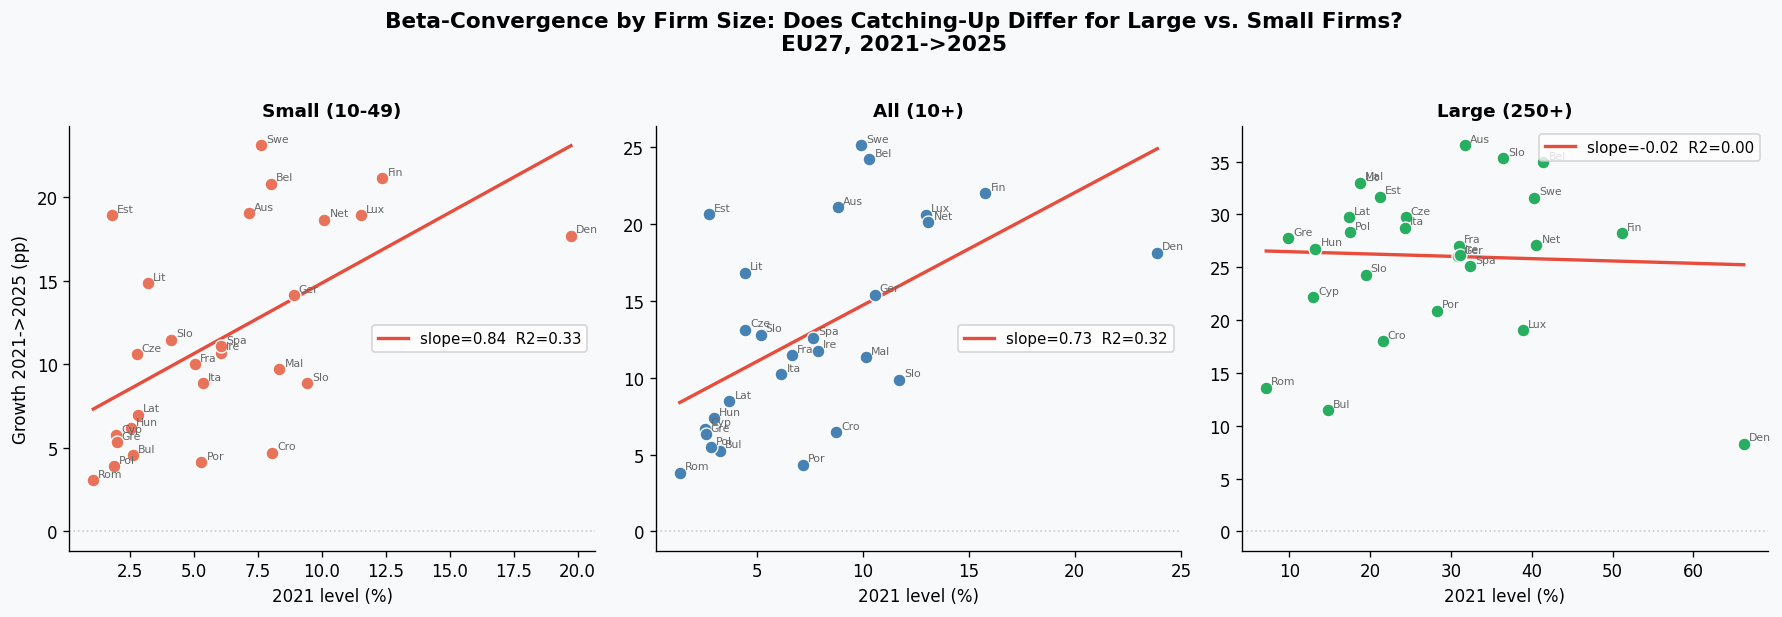

beta-convergence by firm size (2021->2025):
  size class                slope      r2  result
  -------------------------------------------------------
  Small (10-49)             0.844   0.328  diverging
  All (10+)                 0.734   0.319  diverging
  Large (250+)             -0.022   0.002  converging


In [33]:
# beta convergence by firm size - does catching up differ for large vs small firms?
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)
results = {}

for ax, sz, col in zip(axes,
                        ["Small (10-49)", "All (10+)", "Large (250+)"],
                        [C_ORANGE, C_BLUE, C_GREEN]):
    sub  = df_size[df_size["size"] == sz]
    base = sub[sub["yr"] == 2021].set_index("country")["value"]
    end  = sub[sub["yr"] == 2025].set_index("country")["value"]
    com  = sorted(set(base.index) & set(end.index))

    xb = np.array([base[c] for c in com])
    yg = np.array([end[c] - base[c] for c in com])
    m_, b_ = np.polyfit(xb, yg, 1)
    r2_ = np.corrcoef(xb, yg)[0, 1] ** 2
    results[sz] = {"slope": m_, "r2": r2_}

    ax.set_facecolor(BG)
    ax.scatter(xb, yg, color=col, s=60, zorder=3, edgecolors="white", lw=0.8)
    xfit = np.linspace(xb.min(), xb.max(), 200)
    ax.plot(xfit, m_ * xfit + b_, color=C_RED, lw=2,
            label=f"slope={m_:.2f}  R2={r2_:.2f}")
    ax.axhline(0, color=C_GREY, lw=1, linestyle=":")

    for c, xi, yi in zip(com, xb, yg):
        ax.annotate(c[:3], (xi, yi), textcoords="offset points",
                    xytext=(3, 2), fontsize=6.5, color="#666666")

    ax.set_xlabel("2021 level (%)", fontsize=10)
    ax.set_ylabel("Growth 2021->2025 (pp)" if ax is axes[0] else "", fontsize=10)
    ax.set_title(sz, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Beta-Convergence by Firm Size: Does Catching-Up Differ for Large vs. Small Firms?\n"
             "EU27, 2021->2025",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("beta-convergence by firm size (2021->2025):")
print(f"  {'size class':<22} {'slope':>8}  {'r2':>6}  {'result'}")
print("  " + "-"*55)
for sz, r in results.items():
    interp = "converging" if r["slope"] < 0 else "diverging"
    print(f"  {sz:<22} {r['slope']:>8.3f}  {r['r2']:>6.3f}  {interp}")

The most striking finding of this analysis emerges from decomposing β-convergence by firm size. Large firms (250+ employees) exhibit near-perfect convergence (slope=−0.02, R²=0.00), indicating that initial adoption level is entirely uninformative about subsequent growth — large firms in lagging countries catch up to those in leading countries regardless of national context. By contrast, small firms (10–49 employees) display the strongest divergence of any size class (slope=+0.84, R²=0.33), with initial level strongly predicting future growth. This asymmetry reveals that the EU's AI adoption divide is structurally a small-firm problem: large enterprises, subject to global competitive pressure and possessing the internal resources to overcome national institutional barriers, self-converge across borders. Small firms, embedded in local labour markets, dependent on national digital infrastructure and exposed to language barriers in AI tooling, are acutely sensitive to country-level conditions. Policy interventions aimed at EU-wide AI convergence should therefore be targeted specifically at small enterprises in lagging member states, as improving large-firm adoption in these countries would do little to reduce aggregate cross-country inequality

that is it